# CICIDS2018 - Exploratory Analysis

Dataset: CSE-CIC-IDS2018 (Canadian Institute for Cybersecurity / Communications Security
Establishment). Official S3 release, "Processed Traffic Data for ML Algorithms" (CICFlowMeter
flow features), 10 daily CSVs, `data/cicids2018_raw/`. Citation: see `sources.md`.

Each flow record carries a genuine per-flow `Timestamp`, so this notebook establishes real
chronological row order before anything downstream depends on it - a causal, sees-only-past-rows
model needs actual temporal order to be meaningful.

Known raw-data issues handled below, all confirmed against the actual files (not assumed):
- one file (`Thuesday-20-02-2018`) ships 4 extra identifier columns other files don't have
- a handful of rows have the CSV header duplicated as a literal data row (`Label == "Label"`)
- `Timestamp` is a 12-hour clock with no AM/PM marker (hour only ever 1-12)
- 14 rows (out of 16.2M) have a corrupted `01/1970` timestamp, unrelated to the header-duplicate issue
- `Flow Byts/s` / `Flow Pkts/s` contain literal `Infinity` for zero-duration flows

Methodology: streaming quality pass, hash-based dedup, Spearman-rank redundancy analysis.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data/cicids2018_raw"
files = sorted(glob.glob(f"{DATA_DIR}/*.csv"))
print(f"daily files: {len(files)}")

schema = pd.read_csv(files[0], nrows=5)
canonical_cols = schema.columns.tolist()
feature_cols = [c for c in canonical_cols if c not in ("Label", "Timestamp")]
print(f"columns ({len(canonical_cols)}): {canonical_cols}")
print(f"feature columns: {len(feature_cols)}")

# Thuesday-20-02-2018 ships 4 extra identifier columns the other 9 files don't have.
for fp in files:
    extra = [c for c in pd.read_csv(fp, nrows=0).columns if c not in canonical_cols]
    if extra:
        print(f"{os.path.basename(fp)}: extra columns not in the common schema -> {extra}")
schema.head(3)

daily files: 10
columns (80): ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773,202,0,...,20,0,0,0,0,0,0,0,0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0,38,0,...,20,0,0,0,0,0,0,0,0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527,385,0,...,20,0,0,0,0,0,0,0,0,Benign


## 1. Global label distribution (full scan, all 10 files)

In [2]:
label_counts = pd.Series(dtype="int64")
for fp in files:
    df = pd.read_csv(fp, usecols=["Label", "Timestamp"])
    n_junk = int((df["Label"] == "Label").sum())  # duplicated CSV header embedded as a data row
    df = df.loc[df["Label"] != "Label"]
    bad_ts = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S").dt.year != 2018
    n_bad_ts = int(bad_ts.sum())  # separate, tiny artifact: real rows with a corrupted 01/1970 date
    df = df.loc[~bad_ts]
    df["Label"] = df["Label"].str.replace("DDOS attack-", "DDoS attacks-", regex=False)
    label_counts = label_counts.add(df["Label"].value_counts(), fill_value=0)
    if n_junk or n_bad_ts:
        print(f"{os.path.basename(fp)}: dropped {n_junk} header-junk rows, {n_bad_ts} corrupted-timestamp rows")

label_counts = label_counts.astype("int64").sort_values(ascending=False)
total_rows = int(label_counts.sum())
benign_rows = int(label_counts.get("Benign", 0))
print(f"\ntotal rows: {total_rows:,} | classes: {label_counts.shape[0]}")
print(f"benign: {benign_rows:,} ({100*benign_rows/total_rows:.3f}% of all rows)")
label_counts.to_frame("rows")

Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: dropped 1 header-junk rows, 0 corrupted-timestamp rows


Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv: dropped 25 header-junk rows, 0 corrupted-timestamp rows


Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv: dropped 0 header-junk rows, 9 corrupted-timestamp rows


Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: dropped 0 header-junk rows, 5 corrupted-timestamp rows


Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: dropped 33 header-junk rows, 0 corrupted-timestamp rows

total rows: 16,232,929 | classes: 15
benign: 13,484,694 (83.070% of all rows)


,rows
Label,
Benign,13484694
DDoS attacks-HOIC,686012
DDoS attacks-LOIC-HTTP,576191
DoS attacks-Hulk,461912
Bot,286191
FTP-BruteForce,193360
SSH-Bruteforce,187589
Infilteration,161934
DoS attacks-SlowHTTPTest,139890


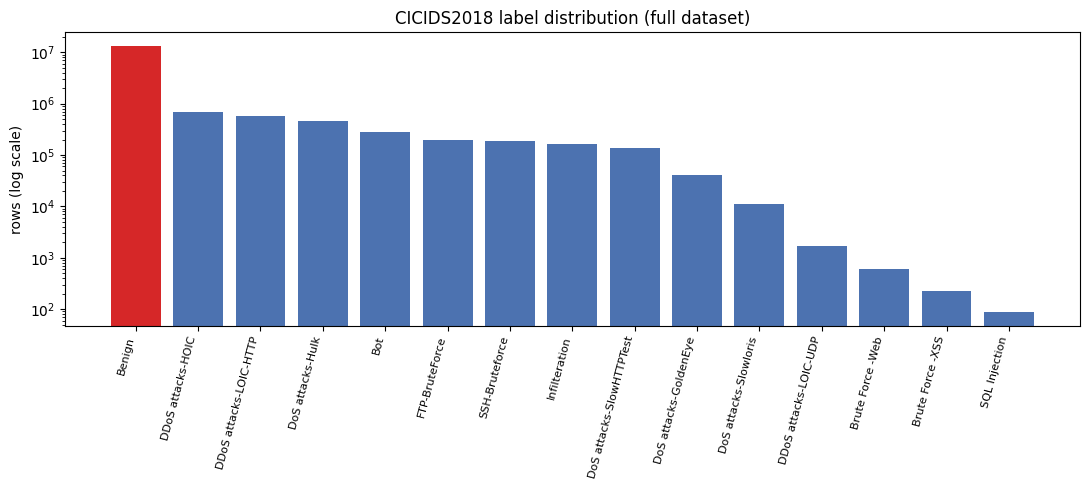

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#d62728" if lbl == "Benign" else "#4c72b0" for lbl in label_counts.index]
ax.bar(range(len(label_counts)), label_counts.values, color=colors)
ax.set_yscale("log")
ax.set_xticks(range(len(label_counts)))
ax.set_xticklabels(label_counts.index, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("rows (log scale)")
ax.set_title("CICIDS2018 label distribution (full dataset)")
plt.tight_layout()
plt.show()

## 2. Full-dataset streaming pass

One file in memory at a time. Aligns the 84-column file to the common 80-column schema, drops
header-junk and corrupted-timestamp rows, normalizes label casing, applies the AM/PM correction
to `Timestamp`, and accumulates null/inf/min per column plus a 64-bit hash per row for duplicate
detection (collision probability across ~16.2M rows is ~(1.6e7)^2 / 2^65 ~ 7e-6, negligible).

`Timestamp` is a 12-hour clock with no AM/PM marker (hour only ever observed in 1-12, confirmed
per-file). CIC's own capture methodology documents a business-hours (~8am-5pm) capture window,
so hours 1-7 are treated as PM (+12h) and 8-12 kept as-is - this is an inferred heuristic, not
verified ground truth, since the raw data itself cannot disambiguate it.

In [4]:
explore_cols = ["Flow Duration", "Tot Fwd Pkts", "Tot Bwd Pkts", "Flow Byts/s", "Flow Pkts/s",
                 "Flow IAT Mean", "Fwd IAT Mean", "Bwd IAT Mean", "Pkt Len Mean", "Pkt Len Std",
                 "Down/Up Ratio", "Active Mean", "Idle Mean", "Init Fwd Win Byts"]
WORK_MM = "data/_rank_work.npy"

n_feat = len(feature_cols)
null_counts = pd.Series(0, index=feature_cols, dtype="int64")
inf_counts = pd.Series(0, index=feature_cols, dtype="int64")
col_min = pd.Series(np.inf, index=feature_cols, dtype="float64")

Xmm = np.lib.format.open_memmap(WORK_MM, mode="w+", dtype="float64",
                                shape=(total_rows, n_feat), fortran_order=True)
print(f"staging workspace: {WORK_MM} ({Xmm.nbytes/1e9:.1f} GB on disk)")

full_hash_parts, feat_hash_parts, explore_parts, dt_parts = [], [], [], []
n_total = 0

for i, fp in enumerate(files):
    chunk = pd.read_csv(fp, low_memory=False)
    extra = [c for c in chunk.columns if c not in canonical_cols]
    if extra:
        chunk = chunk.drop(columns=extra)
    chunk = chunk[canonical_cols]
    chunk = chunk.loc[chunk["Label"] != "Label"].reset_index(drop=True)
    chunk["Label"] = chunk["Label"].str.replace("DDOS attack-", "DDoS attacks-", regex=False)

    ts = pd.to_datetime(chunk["Timestamp"], format="%d/%m/%Y %H:%M:%S")
    bad_ts = ts.dt.year != 2018  # ~14 rows total: a genuine capture-tool artifact, not header junk
    if bad_ts.any():
        chunk = chunk.loc[~bad_ts].reset_index(drop=True)
        ts = ts.loc[~bad_ts].reset_index(drop=True)
    ts = ts + pd.to_timedelta(np.where(ts.dt.hour.between(1, 7), 12, 0), unit="h")
    dt_parts.append(ts.to_numpy())

    X = chunk[feature_cols].apply(pd.to_numeric, errors="coerce")
    null_counts += X.isna().sum()
    Xf = X.to_numpy(dtype="float64")
    inf_counts += pd.Series(np.isinf(Xf).sum(axis=0), index=feature_cols)
    col_min = np.minimum(col_min, X.min())

    Xmm[n_total:n_total + len(chunk), :] = Xf
    n_total += len(chunk)

    full_hash_parts.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())
    feat_hash_parts.append(pd.util.hash_pandas_object(chunk[feature_cols], index=False).to_numpy())

    e = chunk[explore_cols + ["Label"]].copy()
    e["SourceFile"] = os.path.basename(fp)
    for c in explore_cols:
        e[c] = pd.to_numeric(e[c], errors="coerce").astype("float32")
    explore_parts.append(e)

    print(f"  {i+1}/{len(files)} {os.path.basename(fp)}: {len(chunk):,} rows, running total {n_total:,}")

Xmm.flush()
assert n_total == total_rows, f"row count mismatch: {n_total} vs {total_rows}"
print(f"done: {n_total:,} rows processed from {len(files)} files")

staging workspace: data/_rank_work.npy (10.1 GB on disk)


  1/10 Friday-02-03-2018_TrafficForML_CICFlowMeter.csv: 1,048,575 rows, running total 1,048,575


  2/10 Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: 1,048,574 rows, running total 2,097,149


  3/10 Friday-23-02-2018_TrafficForML_CICFlowMeter.csv: 1,048,575 rows, running total 3,145,724


  4/10 Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv: 7,948,748 rows, running total 11,094,472


...

  7/10 Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv: 1,048,566 rows, running total 13,522,713


  8/10 Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: 1,048,570 rows, running total 14,571,283


  9/10 Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv: 1,048,575 rows, running total 15,619,858


  10/10 Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: 613,071 rows, running total 16,232,929


done: 16,232,929 rows processed from 10 files


In [5]:
full_hashes = np.concatenate(full_hash_parts); del full_hash_parts
feat_hashes = np.concatenate(feat_hash_parts); del feat_hash_parts
dt_all = np.concatenate(dt_parts); del dt_parts
wdf = pd.concat(explore_parts, ignore_index=True); del explore_parts
wdf["Label"] = wdf["Label"].astype("category")
print(f"wdf: {wdf.shape}, {wdf.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"time range: {dt_all.min()} -> {dt_all.max()}")

wdf: (16232929, 16), 1.85 GB
time range: 2018-02-14T08:28:20.000000 -> 2018-03-02T17:30:18.000000


## 3. Data quality - nulls, infinities, duplicates, ranges, chronological order

In [6]:
dup_feat = n_total - int(np.unique(feat_hashes).size)
neg_cols = col_min[col_min < 0].index.tolist()

print(f"null cols: {null_counts[null_counts > 0].to_dict()}")
print(f"inf cols: {inf_counts[inf_counts > 0].to_dict()}")
print(f"feature-only duplicate rows (label ignored): {dup_feat:,} ({100*dup_feat/n_total:.4f}%)")
print(f"columns with negative values: {neg_cols}")
print("(Init Fwd/Bwd Win Byts use -1 as a sentinel for 'not applicable', not a real negative measurement)")

null cols: {'Flow Byts/s': 59721}
inf cols: {'Flow Byts/s': 36039, 'Flow Pkts/s': 95760}
feature-only duplicate rows (label ignored): 4,188,480 (25.8024%)
columns with negative values: ['Flow IAT Min', 'Fwd IAT Min', 'Init Fwd Win Byts', 'Init Bwd Win Byts']
(Init Fwd/Bwd Win Byts use -1 as a sentinel for 'not applicable', not a real negative measurement)


In [7]:
# Establish real chronological order, then dedup so "first occurrence" means
# "chronologically first", not "first in whatever order the files happened to be read".
chrono_order = np.argsort(dt_all, kind="stable")
hashes_chrono = full_hashes[chrono_order]

order2 = np.argsort(hashes_chrono, kind="stable")
sorted_h = hashes_chrono[order2]
is_first = np.ones(len(sorted_h), dtype=bool)
is_first[1:] = sorted_h[1:] != sorted_h[:-1]
keep_chrono = np.empty(n_total, dtype=bool)
keep_chrono[order2] = is_first

dup_full = n_total - int(keep_chrono.sum())
print(f"exact duplicate rows (all columns incl. label): {dup_full:,} ({100*dup_full/n_total:.4f}%)")

final_order = chrono_order[keep_chrono]
n_kept = len(final_order)
np.save("data/_final_order.npy", final_order)

dropped_mask = np.ones(n_total, dtype=bool)
dropped_mask[final_order] = False
dropped_labels = wdf.loc[dropped_mask, "Label"].value_counts()
print(f"\ndropping {n_total - n_kept:,} duplicate rows (keeping first occurrence in time)")
print("labels of the dropped rows (duplicate rate is heavily class-skewed - brute-force flows in\n"
      "particular produce many near-simultaneous, byte-identical flow records):")
print(dropped_labels[dropped_labels > 0].to_string())

wdf = wdf.iloc[final_order].reset_index(drop=True)
print(f"\nwdf after chronological sort + dedup: {wdf.shape}")

exact duplicate rows (all columns incl. label): 433,195 (2.6686%)

dropping 433,195 duplicate rows (keeping first occurrence in time)
labels of the dropped rows (duplicate rate is heavily class-skewed - brute-force flows in
particular produce many near-simultaneous, byte-identical flow records):
Label
FTP-BruteForce              154008
DoS attacks-SlowHTTPTest    120428
SSH-Bruteforce               70267
Benign                       39210
DoS attacks-Hulk             27039
DDoS attacks-HOIC            17551
Bot                           3881
DoS attacks-Slowloris          705
DoS attacks-GoldenEye           53
Infilteration                   37
DDoS attacks-LOIC-HTTP          16



wdf after chronological sort + dedup: (15799734, 16)


## 4. Feature redundancy - Spearman rank correlation (exact, full dataset)

Spearman rather than Pearson for the same reason as before: several features are extremely
skewed with heavy tails (`Flow Byts/s`, IAT columns), which Pearson would badly misjudge.

In [8]:
from scipy.stats import rankdata

# Rank each column over the chronologically-sorted, deduplicated rows, writing ranks back into
# the same memmap (fancy-indexed by final_order, so this sorts+dedups+ranks in one pass).
for j, col in enumerate(feature_cols):
    v = np.array(Xmm[:, j], dtype="float64")[final_order]
    Xmm[:n_kept, j] = rankdata(v, method="average", nan_policy="omit")
    del v
Xmm.flush()
print(f"ranked {n_feat} columns over {n_kept:,} rows")

ranked 78 columns over 15,799,734 rows


In [9]:
# Flow Byts/s is the only column with real nulls (59,721 rows with a missing value pre-rank).
# Zero-filling those into the cross-product below would bias every correlation touching that
# column, so exclude them from this computation specifically (listwise deletion, single column).
flow_byts_idx = feature_cols.index("Flow Byts/s")
valid_mask = ~np.isnan(np.asarray(Xmm[:n_kept, flow_byts_idx]))
n_valid = int(valid_mask.sum())
print(f"excluding {n_kept - n_valid:,} rows with a missing Flow Byts/s rank from the correlation computation")

R_sum = np.zeros(n_feat, dtype="float64")
R_XtX = np.zeros((n_feat, n_feat), dtype="float64")
CHUNK = 2_000_000
for s in range(0, n_kept, CHUNK):
    e = min(s + CHUNK, n_kept)
    B = np.asarray(Xmm[s:e, :], dtype="float64")[valid_mask[s:e]]
    R_sum += B.sum(axis=0)
    R_XtX += B.T @ B

mean_r = R_sum / n_valid
cov_r = R_XtX / n_valid - np.outer(mean_r, mean_r)
std_r = np.sqrt(np.clip(np.diag(cov_r), 0, None))

zero_var = [c for c, s in zip(feature_cols, std_r) if s == 0]
print(f"zero-variance (constant) columns, dropped below: {zero_var}")

denom = np.outer(std_r, std_r)
with np.errstate(invalid="ignore", divide="ignore"):
    spearman_full = pd.DataFrame(np.where(denom > 0, cov_r / denom, np.nan),
                            index=feature_cols, columns=feature_cols)
spearman_full.to_csv("data/spearman_full.csv")
print("saved data/spearman_full.csv")

excluding 58,342 rows with a missing Flow Byts/s rank from the correlation computation


zero-variance (constant) columns, dropped below: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
saved data/spearman_full.csv


### Dropping near-duplicate features (|Spearman rho| > 0.99) before the heatmap

Pairs this correlated are effectively the same column (e.g. `Tot Fwd Pkts` and its own
`Subflow Fwd Pkts` restatement) - keeps the lexicographically-first name in each near-duplicate
group. Zero-variance (constant) columns are dropped here too: their correlation with everything
is undefined, so leaving them in would just show up as blank rows in the heatmap below.

In [10]:
all_cols = [c for c in feature_cols if c not in zero_var]

parent = {c: c for c in all_cols}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

dup_edges = []
for i in range(len(all_cols)):
    for j in range(i + 1, len(all_cols)):
        r = spearman_full.loc[all_cols[i], all_cols[j]]
        if pd.notna(r) and abs(r) > 0.99:
            dup_edges.append((all_cols[i], all_cols[j], round(float(r), 4)))
            union(all_cols[i], all_cols[j])

from collections import defaultdict
groups = defaultdict(list)
for c in all_cols:
    groups[find(c)].append(c)

dropped_features = list(zero_var)
print(f"edges with |Spearman rho| > 0.99: {len(dup_edges)}")
for a, b, r in dup_edges:
    print(f"  {a:20s} <-> {b:20s}  rho={r}")

print("\nnear-duplicate groups (kept -> dropped):")
for members in groups.values():
    if len(members) > 1:
        members_sorted = sorted(members)
        keep, drop = members_sorted[0], members_sorted[1:]
        dropped_features.extend(drop)
        print(f"  keep {keep!r:24s} drop {drop}")

dropped_features = sorted(dropped_features)
feature_cols_kept = [c for c in all_cols if c not in dropped_features]
spearman_kept = spearman_full.loc[feature_cols_kept, feature_cols_kept]

print(f"\nDROPPED ({len(dropped_features)}/{len(feature_cols)}): {dropped_features}")
print(f"remaining features: {len(feature_cols_kept)}")

edges with |Spearman rho| > 0.99: 29
  Flow Duration        <-> Flow IAT Max          rho=0.9916
  Tot Fwd Pkts         <-> Subflow Fwd Pkts      rho=1.0
  Tot Bwd Pkts         <-> Subflow Bwd Pkts      rho=1.0
  TotLen Fwd Pkts      <-> Subflow Fwd Byts      rho=1.0
  TotLen Bwd Pkts      <-> Bwd Pkt Len Max       rho=0.9925
  TotLen Bwd Pkts      <-> Subflow Bwd Byts      rho=1.0
  Fwd Pkt Len Min      <-> Pkt Len Min           rho=0.9961
  Fwd Pkt Len Mean     <-> Fwd Seg Size Avg      rho=1.0
  Bwd Pkt Len Max      <-> Subflow Bwd Byts      rho=0.9925
  Bwd Pkt Len Mean     <-> Bwd Seg Size Avg      rho=1.0
  Flow Pkts/s          <-> Flow IAT Mean         rho=-0.9985
  Flow Pkts/s          <-> Flow IAT Max          rho=-0.9938
  Fwd IAT Tot          <-> Fwd IAT Mean          rho=0.9916
  Fwd IAT Tot          <-> Fwd IAT Max           rho=0.9961
  Fwd IAT Mean         <-> Fwd IAT Max           rho=0.9957
  Bwd IAT Tot          <-> Bwd IAT Mean          rho=0.997
  Bwd IAT Tot       

### Dropping isolated features (median |Spearman rho| <= 0.01 against every remaining feature)

The opposite problem from redundancy: a feature whose typical correlation with the rest of the kept set is near zero in
the kept set. Not necessarily noise, but not adding structure this correlation-based analysis
can see either - dropped for the same reason near-duplicates are, just at the other end.

In [11]:
max_corr = spearman_kept.abs().where(~np.eye(len(feature_cols_kept), dtype=bool)).median(axis=1)
isolated = max_corr[max_corr <= 0.01].index.tolist()

print(f"features with median |rho| <= 0.01 against every other kept feature: {len(isolated)}")
for f in isolated:
    print(f"  {f:24s} median |rho| = {max_corr[f]:.4f}")

dropped_features = sorted(set(dropped_features) | set(isolated))
feature_cols_kept = [c for c in feature_cols_kept if c not in isolated]
spearman_kept = spearman_full.loc[feature_cols_kept, feature_cols_kept]

print(f"\nremoved {len(isolated)} isolated features; {len(feature_cols_kept)} features remain")

features with median |rho| <= 0.01 against every other kept feature: 0

removed 0 isolated features; 46 features remain


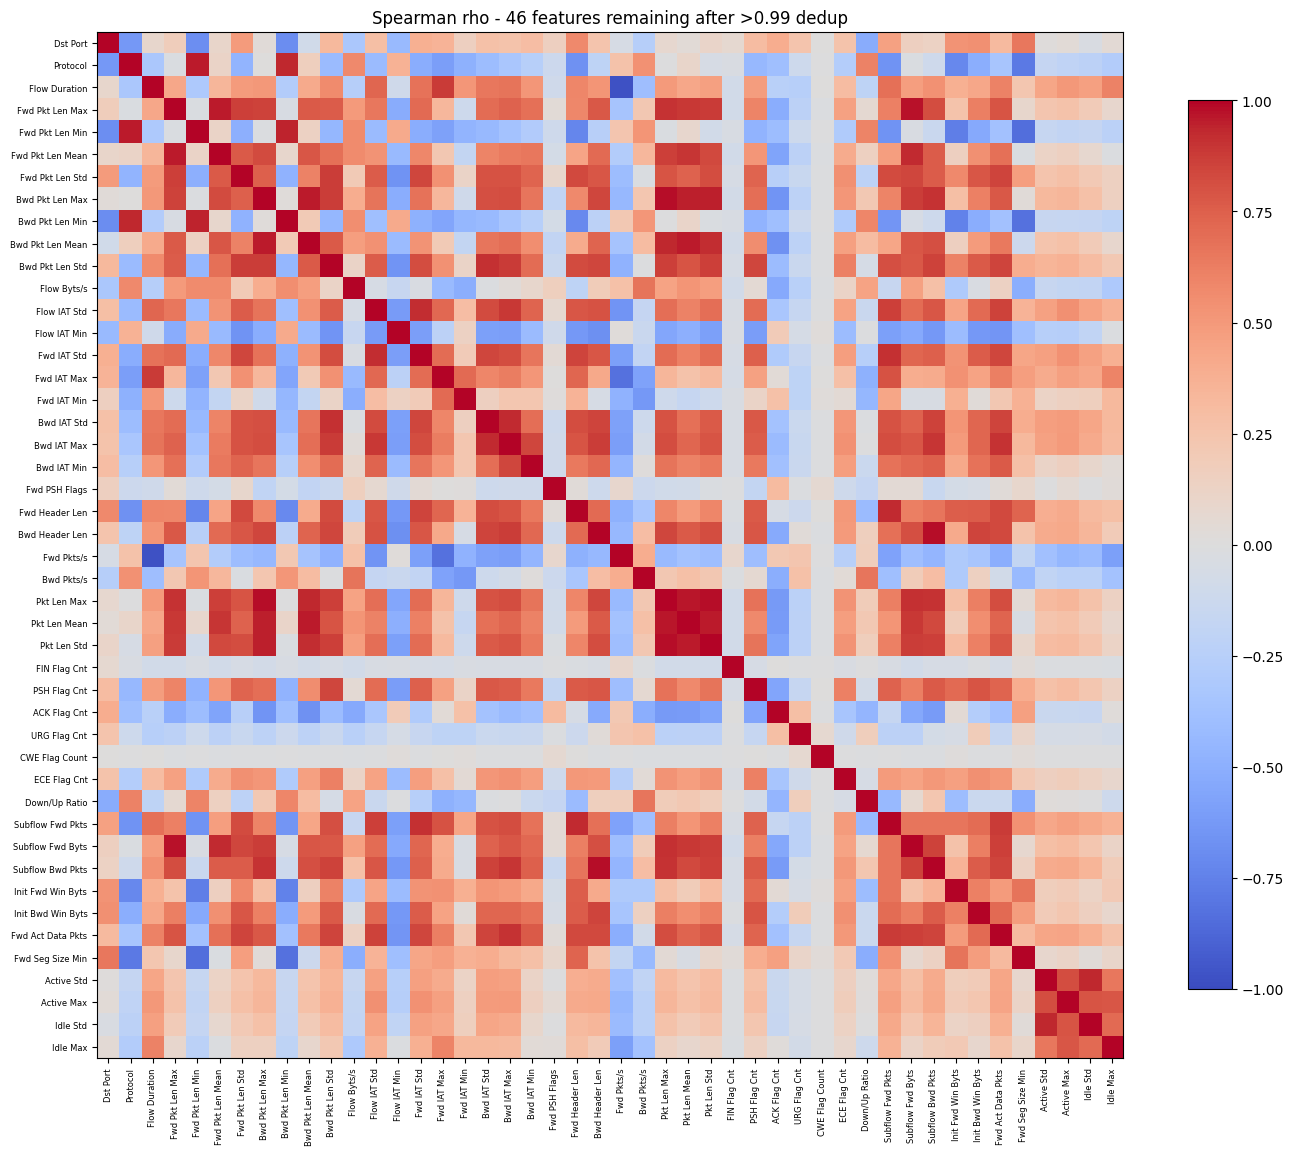

In [12]:
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(spearman_kept, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols_kept))); ax.set_xticklabels(feature_cols_kept, rotation=90, fontsize=6)
ax.set_yticks(range(len(feature_cols_kept))); ax.set_yticklabels(feature_cols_kept, fontsize=6)
ax.set_title(f"Spearman rho - {len(feature_cols_kept)} features remaining after >0.99 dedup")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [13]:
pairs = []
for i in range(len(feature_cols_kept)):
    for j in range(i + 1, len(feature_cols_kept)):
        r = spearman_kept.iloc[i, j]
        if pd.notna(r) and abs(r) >= 0.97:
            pairs.append((feature_cols_kept[i], feature_cols_kept[j], round(float(r), 4)))
pairs.sort(key=lambda x: -abs(x[2]))
print(f"feature pairs with |Spearman rho| >= 0.97 (post-drop): {len(pairs)}")
for p in pairs:
    print(f"  {p[0]:20s} <-> {p[1]:20s}  rho={p[2]}")

feature pairs with |Spearman rho| >= 0.97 (post-drop): 5
  Bwd Pkt Len Max      <-> Pkt Len Max           rho=0.9815
  Bwd Header Len       <-> Subflow Bwd Pkts      rho=0.9774
  Pkt Len Max          <-> Pkt Len Std           rho=0.9774
  Fwd Pkt Len Max      <-> Subflow Fwd Byts      rho=0.9755
  Flow Duration        <-> Fwd Pkts/s            rho=-0.9715


### Widening to |rho| >= 0.9 - remaining candidates for the pairwise redundancy test

Everything above |rho| > 0.99 was already dropped at the source above. This is the candidate
list for a downstream pairwise redundancy test (unchanged methodology - not re-run here); which
of these to actually drop for the zero-shot setup is a separate, manual decision.

In [14]:
pairs_0_9 = []
for i in range(len(feature_cols_kept)):
    for j in range(i + 1, len(feature_cols_kept)):
        r = spearman_kept.iloc[i, j]
        if pd.notna(r) and abs(r) >= 0.9:
            pairs_0_9.append((feature_cols_kept[i], feature_cols_kept[j], round(float(r), 4)))
pairs_0_9.sort(key=lambda x: -abs(x[2]))

print(f"pairs with |rho| >= 0.9 among the {len(feature_cols_kept)} post-drop features: {len(pairs_0_9)}")
for p in pairs_0_9:
    print(f"    {p[0]:20s} <-> {p[1]:20s}  rho={p[2]}")

import json
json.dump({"feature_cols_kept": feature_cols_kept, "dropped_features": dropped_features,
           "pairs_ge_0_9": pairs_0_9}, open("data/pairs_ge_0_9.json", "w"), indent=2)
print("\nsaved data/pairs_ge_0_9.json")

pairs with |rho| >= 0.9 among the 46 post-drop features: 28
    Bwd Pkt Len Max      <-> Pkt Len Max           rho=0.9815
    Bwd Header Len       <-> Subflow Bwd Pkts      rho=0.9774
    Pkt Len Max          <-> Pkt Len Std           rho=0.9774
    Fwd Pkt Len Max      <-> Subflow Fwd Byts      rho=0.9755
    Flow Duration        <-> Fwd Pkts/s            rho=-0.9715
    Pkt Len Max          <-> Pkt Len Mean          rho=0.9654
    Protocol             <-> Fwd Pkt Len Min       rho=0.9592
    Bwd Pkt Len Mean     <-> Pkt Len Mean          rho=0.9575
    Fwd Pkt Len Max      <-> Fwd Pkt Len Mean      rho=0.954
    Bwd Pkt Len Max      <-> Bwd Pkt Len Mean      rho=0.9538
    Pkt Len Mean         <-> Pkt Len Std           rho=0.9532
    Bwd Pkt Len Max      <-> Pkt Len Std           rho=0.9513
    Bwd Pkt Len Max      <-> Pkt Len Mean          rho=0.9463
    Fwd Pkt Len Min      <-> Bwd Pkt Len Min       rho=0.9417
    Protocol             <-> Bwd Pkt Len Min       rho=0.9367
    Active

## 5. Zero-duration flow artifact - `Flow Byts/s` / `Flow Pkts/s` -> Infinity

CICFlowMeter divides total bytes/packets by flow duration to get these two rate features. A
flow that starts and ends within the same microsecond has `Flow Duration == 0`, which forces a
division by zero - the literal string `"Infinity"` in the raw CSV, parsed above straight into
`np.inf`.

In [15]:
zero_dur = wdf["Flow Duration"] == 0
inf_rate = ~np.isfinite(wdf["Flow Byts/s"]) | ~np.isfinite(wdf["Flow Pkts/s"])

print(f"zero-duration flows: {int(zero_dur.sum()):,} ({100*zero_dur.mean():.3f}% of kept rows)")
print(f"non-finite Flow Byts/s or Flow Pkts/s: {int(inf_rate.sum()):,} ({100*inf_rate.mean():.3f}%)")
print(f"zero-duration rows that are also non-finite-rate: {int((zero_dur & inf_rate).sum()):,} "
      f"of {int(zero_dur.sum()):,} zero-duration rows")

by_label = wdf.loc[inf_rate, "Label"].value_counts()
by_label = by_label[by_label > 0]
print("\nnon-finite-rate rows by label:")
print(by_label.to_string())

zero-duration flows: 94,296 (0.597% of kept rows)
non-finite Flow Byts/s or Flow Pkts/s: 94,296 (0.597%)
zero-duration rows that are also non-finite-rate: 94,296 of 94,296 zero-duration rows

non-finite-rate rows by label:
Label
Benign            92997
Infilteration      1293
FTP-BruteForce        6


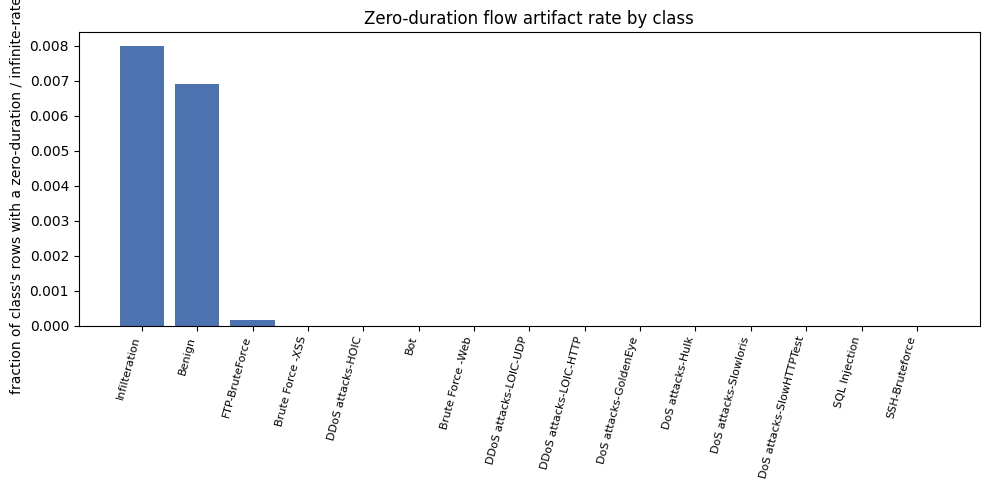

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
rate = by_label.reindex(wdf["Label"].cat.categories).fillna(0)
share = rate / wdf["Label"].value_counts()
share = share.dropna().sort_values(ascending=False)
ax.bar(range(len(share)), share.values, color="#4c72b0")
ax.set_xticks(range(len(share))); ax.set_xticklabels(share.index, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("fraction of class's rows with a zero-duration / infinite-rate flow")
ax.set_title("Zero-duration flow artifact rate by class")
plt.tight_layout()
plt.show()

## 6. Single-feature separability probe - `Flow Byts/s` by class

In [17]:
rate_by_label = wdf.replace([np.inf, -np.inf], np.nan).groupby("Label", observed=True)["Flow Byts/s"] \
    .describe()[["min", "25%", "50%", "75%", "max"]]
rate_by_label.sort_values("50%")

,min,25%,50%,75%,max
Label,,,,,
DDoS attacks-HOIC,0.000000,0.000000,0.000000,0.000000,1.911677e+06
FTP-BruteForce,0.000000,0.000000,0.000000,0.000000,0.000000e+00
DoS attacks-SlowHTTPTest,0.000000,0.000000,0.000000,0.000000,0.000000e+00
DoS attacks-Hulk,0.000000,0.000000,0.000000,0.000000,1.730137e+06
DoS attacks-Slowloris,0.000000,0.136700,22.031555,23.565962,2.300000e+08
Brute Force -Web,0.000000,0.000000,33.527218,201.833046,1.037954e+06
Brute Force -XSS,0.000000,0.000000,33.527258,4313.909912,9.318519e+05
DoS attacks-GoldenEye,0.000000,0.000000,122.324898,249.825691,2.233333e+07
SQL Injection,0.000000,0.000000,192.806656,494.265854,4.507513e+03


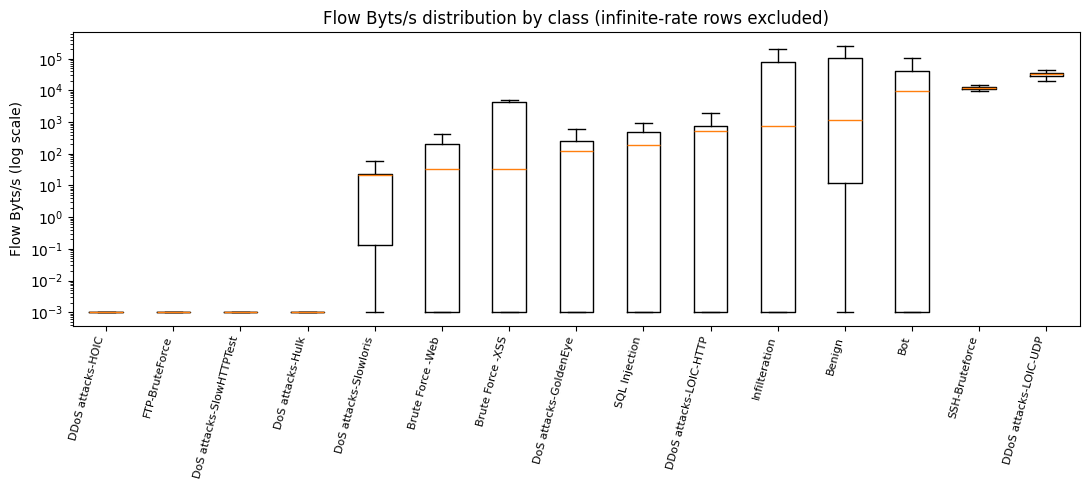

In [18]:
order = rate_by_label.sort_values("50%").index
fig, ax = plt.subplots(figsize=(11, 5))
data = [wdf.loc[wdf.Label == lbl, "Flow Byts/s"].replace([np.inf, -np.inf], np.nan).dropna().clip(lower=1e-3)
        for lbl in order]
ax.boxplot(data, showfliers=False)
ax.set_xticklabels(order, rotation=75, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("Flow Byts/s (log scale)")
ax.set_title("Flow Byts/s distribution by class (infinite-rate rows excluded)")
plt.tight_layout()
plt.show()

## 7. Q-Q plots - 15 random post-drop features, 30k random rows

Sampled directly from the raw CSVs (not from the ranked staging memmap, which holds rank values
by this point, not the original distribution shapes) - a downstream `features_train.npy`
doesn't exist yet for this dataset, so this reads fresh.

sample: 30,000 rows x 15 columns


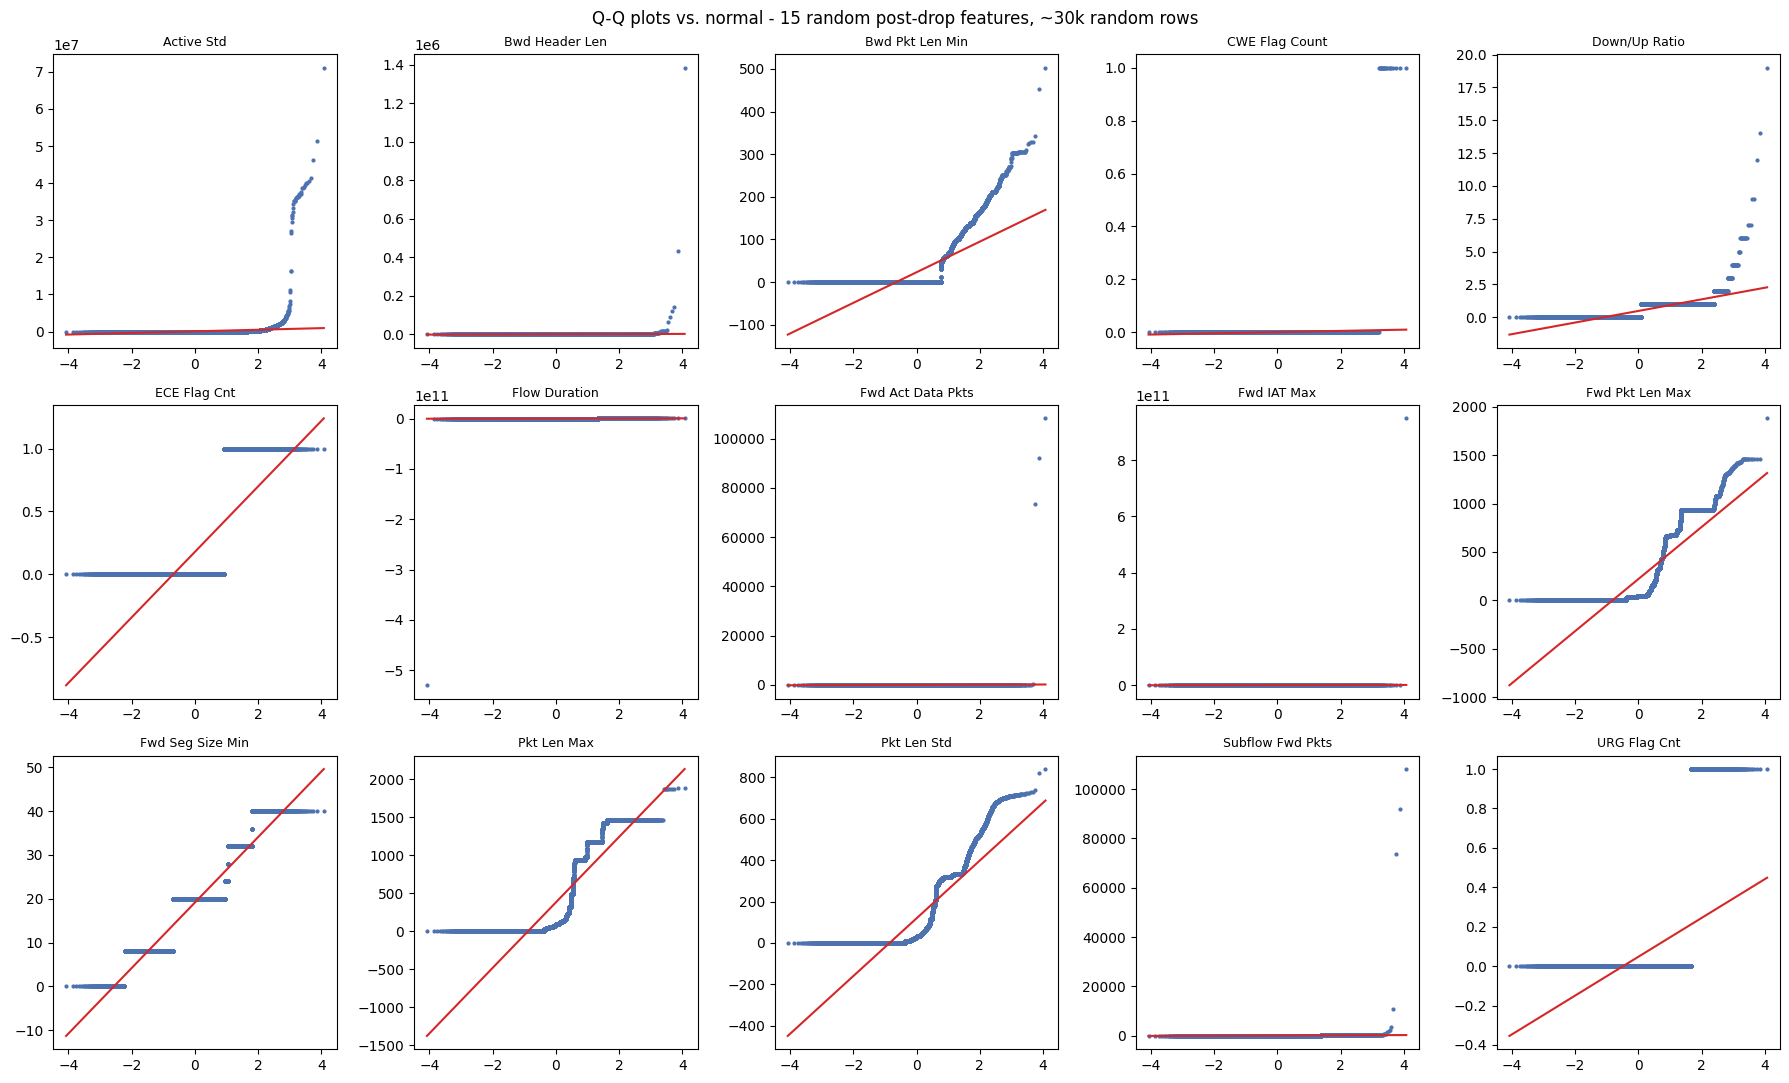

In [19]:
from scipy import stats

rng = np.random.default_rng(42)
sample_cols = sorted(rng.choice(feature_cols_kept, size=15, replace=False).tolist())

parts = []
for fp in files:
    df = pd.read_csv(fp, usecols=sample_cols, low_memory=False)
    n = min(4000, len(df))
    idx = rng.choice(len(df), size=n, replace=False)
    parts.append(df.iloc[idx].apply(pd.to_numeric, errors="coerce"))
sample = pd.concat(parts, ignore_index=True).dropna()
sample = sample.sample(n=min(30_000, len(sample)), random_state=42)
print(f"sample: {len(sample):,} rows x {len(sample_cols)} columns")

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for ax, col in zip(axes.flat, sample_cols):
    stats.probplot(sample[col], dist="norm", plot=ax)
    ax.set_title(col, fontsize=9)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_color("#4c72b0")
    ax.get_lines()[1].set_color("#d62728")
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Q-Q plots vs. normal - 15 random post-drop features, ~30k random rows")
plt.tight_layout()
plt.show()

## 8. Per-file fit/val/test split (0-25% / 25-50% / 50-100%), then per-piece benign downsampling

Each file is split into its three pieces *before* any cross-file concatenation - fit and val
come from within a file's own first half, test from its second half (zero-shot). Concatenation
across the 10 files happens only after this per-file split, so no split boundary ever crosses a
file boundary; nothing is shuffled at any point. Full 46-feature set (`feature_cols_kept`), not
the 14-column EDA subset - built fresh from the raw CSVs since the ranking memmap no longer
holds original values. Benign downsampling (cap at that piece's own largest attack class, dirty
non-finite rows dropped first) runs independently within each of the three pieces.

In [20]:
dirty_extra = [] if "Flow Pkts/s" in feature_cols_kept else ["Flow Pkts/s"]
read_cols = list(dict.fromkeys(feature_cols_kept + dirty_extra + ["Label", "Timestamp"]))

full_parts = []
for fp in files:
    chunk = pd.read_csv(fp, usecols=lambda c: c in read_cols or c in ("Flow ID", "Src IP", "Src Port", "Dst IP"),
                         low_memory=False)
    extra = [c for c in chunk.columns if c not in canonical_cols]
    if extra:
        chunk = chunk.drop(columns=extra)
    chunk = chunk.loc[chunk["Label"] != "Label"].reset_index(drop=True)
    chunk["Label"] = chunk["Label"].str.replace("DDOS attack-", "DDoS attacks-", regex=False)

    ts = pd.to_datetime(chunk["Timestamp"], format="%d/%m/%Y %H:%M:%S")
    bad_ts = ts.dt.year != 2018
    if bad_ts.any():
        chunk = chunk.loc[~bad_ts].reset_index(drop=True)

    part = chunk[feature_cols_kept + dirty_extra + ["Label"]].apply(
        lambda s: pd.to_numeric(s, errors="coerce") if s.name != "Label" else s)
    part["SourceFile"] = os.path.basename(fp)
    full_parts.append(part)

wdf_full = pd.concat(full_parts, ignore_index=True)
wdf_full = wdf_full.iloc[final_order].reset_index(drop=True)
wdf_full["_dirty"] = ~np.isfinite(wdf_full["Flow Byts/s"]) | ~np.isfinite(wdf_full["Flow Pkts/s"])
print(f"wdf_full: {wdf_full.shape}")

wdf_full: (15799734, 50)


In [21]:
def downsample_benign(df, seed):
    rng = np.random.default_rng(seed)
    drop_idx_parts = []
    summary_rows = []
    for src, g in df.groupby("SourceFile", observed=True):
        counts = g["Label"].value_counts()
        attack_counts = counts[(counts.index != "Benign") & (counts > 0)]
        if attack_counts.empty:
            continue
        target = int(attack_counts.max())

        benign_g = g.loc[g["Label"] == "Benign"]
        benign_n = len(benign_g)
        if benign_n <= target:
            summary_rows.append({"file": src, "benign_before": benign_n, "target": target,
                                  "benign_after": benign_n, "dropped": 0, "dirty_dropped": 0})
            continue

        drop_n = benign_n - target
        dirty_idx = benign_g.index[benign_g["_dirty"]].to_numpy()
        clean_idx = benign_g.index[~benign_g["_dirty"]].to_numpy()
        if len(dirty_idx) >= drop_n:
            drop_sel = rng.choice(dirty_idx, size=drop_n, replace=False)
            n_dirty_dropped = drop_n
        else:
            extra = drop_n - len(dirty_idx)
            drop_sel = np.concatenate([dirty_idx, rng.choice(clean_idx, size=extra, replace=False)])
            n_dirty_dropped = len(dirty_idx)

        drop_idx_parts.append(drop_sel)
        summary_rows.append({"file": src, "benign_before": benign_n, "target": target,
                              "benign_after": benign_n - drop_n, "dropped": drop_n,
                              "dirty_dropped": n_dirty_dropped})

    drop_idx = np.concatenate(drop_idx_parts) if drop_idx_parts else np.array([], dtype=np.int64)
    keep = pd.Series(True, index=df.index)
    keep.loc[drop_idx] = False
    summary = pd.DataFrame(summary_rows).set_index("file")
    return df.loc[keep].drop(columns="_dirty", errors="ignore").reset_index(drop=True), summary


fit_parts, val_parts, test_parts = [], [], []
for src, g in wdf_full.groupby("SourceFile", observed=True, sort=False):
    n = len(g)
    q1, q2 = n // 4, n // 2
    fit_parts.append(g.iloc[:q1])
    val_parts.append(g.iloc[q1:q2])
    test_parts.append(g.iloc[q2:])

fit_pool = pd.concat(fit_parts)
val_pool = pd.concat(val_parts)
test_pool = pd.concat(test_parts)
print(f"fit pool  (0-25% per file):   {len(fit_pool):,} rows")
print(f"val pool  (25-50% per file):  {len(val_pool):,} rows")
print(f"test pool (50-100% per file, zero-shot): {len(test_pool):,} rows")

fit_full, fit_summary = downsample_benign(fit_pool, seed=42)
val_full, val_summary = downsample_benign(val_pool, seed=43)
test_full, test_summary = downsample_benign(test_pool, seed=44)
print(f"\nafter benign downsampling - fit: {len(fit_full):,}  val: {len(val_full):,}  test: {len(test_full):,}")

fit pool  (0-25% per file):   3,949,930 rows
val pool  (25-50% per file):  3,949,936 rows
test pool (50-100% per file, zero-shot): 7,899,868 rows



after benign downsampling - fit: 1,351,847  val: 1,714,428  test: 2,170,067


In [22]:
def drop_residual_dirty(df, name):
    dirty = ~np.isfinite(df[feature_cols_kept]).all(axis=1)
    print(f"{name}: residual non-finite rows = {int(dirty.sum()):,}")
    if dirty.any():
        print(df.loc[dirty, "Label"].value_counts().to_string())
    return df.loc[~dirty].reset_index(drop=True)

fit_full = drop_residual_dirty(fit_full, "fit")
val_full = drop_residual_dirty(val_full, "val")
test_full = drop_residual_dirty(test_full, "test")
print(f"\nafter cleanup - fit: {len(fit_full):,}  val: {len(val_full):,}  test: {len(test_full):,}")

for name, df in [("fit", fit_full), ("val", val_full), ("test", test_full)]:
    print(f"\n{name} class counts:")
    print(df["Label"].value_counts().to_string())

fit: residual non-finite rows = 2,217
Label
Benign           2120
Infilteration      97


val: residual non-finite rows = 499
Label
Infilteration     494
FTP-BruteForce      5


test: residual non-finite rows = 4,952
Label
Benign            4249
Infilteration      702
FTP-BruteForce       1



after cleanup - fit: 1,349,630  val: 1,713,929  test: 2,165,115

fit class counts:
Label
Benign                      714947
DDoS attacks-HOIC           253796
DDoS attacks-LOIC-HTTP      173010
DoS attacks-Hulk            104109
DoS attacks-GoldenEye        39494
Bot                          26915
DoS attacks-SlowHTTPTest     19462
Infilteration                16012
DDoS attacks-LOIC-UDP         1730
Brute Force -Web               155

val class counts:
Label
Benign                    822320
DDoS attacks-LOIC-HTTP    402368
DDoS attacks-HOIC         162789
Bot                       109257
DoS attacks-Hulk          107902
Infilteration              64891
FTP-BruteForce             31696
DoS attacks-Slowloris      10285
DoS attacks-GoldenEye       1961
Brute Force -Web             456
SQL Injection                  4

test class counts:
Label
Benign                    1338456
DDoS attacks-HOIC          251876
DoS attacks-Hulk           222862
Bot                        146138
SSH-Brutef

## 9. Scaling and label encoding

Every kept feature gets a signed-log transform (`sign(x) * log1p(|x|)`) before `RobustScaler` -
several columns (Idle/Active Max/Std, IAT, byte/pkt counts) are heavily right-skewed with a
near-zero IQR, which otherwise blows rare large values up to ~1e8 after scaling and drowns out
every other feature. `RobustScaler` is fit on fit only, applied unchanged to val and test -
neither ever influences the scaling. Label IDs are assigned over the union of fit/val/test, so a
class absent from fit (zero-shot at training time) still gets a stable, defined ID.

In [23]:
from sklearn.preprocessing import RobustScaler
import json as _json

# Signed log (ln) on every feature column before scaling: sign(x) * log1p(|x|).
# Several columns (Idle/Active Max/Std, IAT, byte/pkt counts) are heavily right-skewed with a
# near-zero IQR, so plain RobustScaler blows rare large values up to ~1e8 and drowns out the
# other features gradient-wise. log1p(|x|) compresses that tail; sign(x) preserves CICFlowMeter
# sentinel negatives (e.g. Init Fwd/Bwd Win Byts == -1) without producing -inf/NaN like a plain
# log would. Applied uniformly to all 46 kept feature columns, not just the skewed ones.
def signed_log(a):
    return np.sign(a) * np.log1p(np.abs(a))

X_fit_raw = signed_log(fit_full[feature_cols_kept].to_numpy(dtype="float64"))
X_val_raw = signed_log(val_full[feature_cols_kept].to_numpy(dtype="float64"))
X_test_raw = signed_log(test_full[feature_cols_kept].to_numpy(dtype="float64"))

scaler = RobustScaler()
X_fit = scaler.fit_transform(X_fit_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")
print(f"X_fit: {X_fit.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"post-scale max_abs: fit={np.abs(X_fit).max():.3f}  val={np.abs(X_val).max():.3f}  test={np.abs(X_test).max():.3f}")

all_labels = sorted(set(fit_full["Label"]) | set(val_full["Label"]) | set(test_full["Label"]))
label_to_id = {lbl: i for i, lbl in enumerate(all_labels)}
print(f"\n{len(label_to_id)} classes (fit u val u test):")
for lbl, i in label_to_id.items():
    print(f"  {i:2d} -> {lbl}")

y_fit = fit_full["Label"].map(label_to_id).to_numpy().astype("int16")
y_val = val_full["Label"].map(label_to_id).to_numpy().astype("int16")
y_test = test_full["Label"].map(label_to_id).to_numpy().astype("int16")

np.save("data/features_fit.npy", X_fit)
np.save("data/labels_fit.npy", y_fit)
np.save("data/features_val.npy", X_val)
np.save("data/labels_val.npy", y_val)
np.save("data/features_test.npy", X_test)
np.save("data/labels_test.npy", y_test)
_json.dump(feature_cols_kept, open("data/feature_columns.json", "w"), indent=2)
_json.dump(label_to_id, open("data/label_mapping.json", "w"), indent=2)

print("\nsaved: features_fit/labels_fit.npy, features_val/labels_val.npy, features_test/labels_test.npy,")
print("       feature_columns.json, label_mapping.json")

X_fit: (1349630, 46)  X_val: (1713929, 46)  X_test: (2165115, 46)


post-scale max_abs: fit=22.600  val=18.603  test=22.403



15 classes (fit u val u test):
   0 -> Benign
   1 -> Bot
   2 -> Brute Force -Web
   3 -> Brute Force -XSS
   4 -> DDoS attacks-HOIC
   5 -> DDoS attacks-LOIC-HTTP
   6 -> DDoS attacks-LOIC-UDP
   7 -> DoS attacks-GoldenEye
   8 -> DoS attacks-Hulk
   9 -> DoS attacks-SlowHTTPTest
  10 -> DoS attacks-Slowloris
  11 -> FTP-BruteForce
  12 -> Infilteration
  13 -> SQL Injection
  14 -> SSH-Bruteforce



saved: features_fit/labels_fit.npy, features_val/labels_val.npy, features_test/labels_test.npy,
       feature_columns.json, label_mapping.json
